In [1]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import localcider
from localcider.sequenceParameters import SequenceParameters
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import pathlib
from matplotlib import font_manager
from scipy.stats import fisher_exact
from scipy.stats import chisquare

# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

#COLOR_MAP = dict()
#COLOR_MAP['A']         = '#8c8c8c'
#COLOR_MAP['CHNQST']    = '#077a15'
#COLOR_MAP['DE']        = '#e23a36'
#COLOR_MAP['FWY']       = '#f58220'
#COLOR_MAP['G']         = '#86bd8d'
#COLOR_MAP['ILMV']      = '#231f20'
#COLOR_MAP['KR']        = '#1725c2'
#COLOR_MAP['P']         = '#c25fc9'

# Kiersten's colors
COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#1f8241'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#d865a6'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#189bd7'
COLOR_MAP['P']         = '#7c2880'
COLOR_MAP['-']         = '#000000'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

/home/research/kiersten.ruff/fonts/ARIAL.TTF


## 1.1 - Load in Exceptional IDRs in Cancer Driver Genes

In [2]:
expcancerIDRsdf=pd.read_excel('data/COSMIC_data/Cancer_driver_genes_house_exceptional_IDRs_with_type_and_IDRs.xlsx')
print(expcancerIDRsdf)

    Unnamed: 0         Gene Accession             Feature  Rank  Start Pos  \
0            0  KMT2D IDR10    O14686  Cumulative Patch Q     1       3712   
1            1  ARID1A IDR1    O14497  Cumulative Patch Q    26          0   
2            2  NOTCH1 IDR2    P46531  Cumulative Patch Q    78       2364   
3            3  CREBBP IDR9    Q92793  Cumulative Patch Q    13       2108   
4            4   ARID2 IDR4    Q68CP9  Cumulative Patch Q    70        953   
..         ...          ...       ...                 ...   ...        ...   
71          71  SETD1B IDR5    Q9UPS6             neg-neg    49        959   
72          72    DAXX IDR3    Q9UER7             neg-neg    50        371   
73          73   KAT6B IDR5    Q8WYB5             neg-neg    12        995   
74          74   CASZ1 IDR9    Q86V15             neg-neg    15       1640   
75          75  BCL11A IDR4    Q9H165             neg-neg    44        464   

    End Pos  IDR Length  Full Protein Length  \
0      4191    

## 1.2 - Load in full protein sequences

In [3]:
## Load in sequences
myfile = open('../general_data/UP000005640_9606.fasta', 'r')
Lines = myfile.readlines()

subfullprotaccs=[]
subfullprotseqs=[]
thisseq = ''
for line in Lines:
    
    # remove pesky newline
    cleanline = line.strip()
    
    
    if cleanline[0]=='>':
        subfullprotaccs.append(cleanline.split('|')[1])
        
        # check that this is not the very first sequence, if not 
        # add the sequence
        if (thisseq is not ''): 
            subfullprotseqs.append(thisseq.upper()) 

            # reset the sequence for the coming entry
            thisseq = '' 

    # else append the sequence
    else:
        thisseq += cleanline

# store the final sequence	
subfullprotseqs.append(thisseq.upper()) 

print(len(subfullprotaccs))
print(len(subfullprotseqs))
print(subfullprotaccs[0])
print(subfullprotseqs[0])

20882
20882
A0A024RAP8
MGWIRGRRSRHSWEMSEFHNYNLDLKKSDFSTRWQKQRCPVVKSKCRENASPFFFCCFIAVAMGIRFIIMVTIWSAVFLNSLFNQEVQIPLTESYCGPCPKNWICYKNNCYQFFDESKNWYESQASCMSQNASLLKVYSKEDQDLLKLVKSYHWMGLVHIPTNGSWQWEDGSILSPNLLTIIEMQKGDCALYASSFKGYIENCSTPNTYICMQRTV


## 1.3 - Check which sequences match the sequences in the COSMIC data

In [4]:
goodgenes=[]
unimuttypes=[]
for i in range(0,len(expcancerIDRsdf)):
    #if expcancerIDRsdf['Feature'].tolist()[i] not in ['Num M','Num Y','Num P']:
    currgene=expcancerIDRsdf['Gene'].tolist()[i].split(' ')[0]
    print(currgene)

    if currgene!='TAF15': # TAF15 had no COSMIC mutations
        currdf=pd.read_table('data/COSMIC_data/'+currgene+'_Gene_mutations_COSMIC.tsv')

        #print(currdf)
        currmutlist=currdf['AA Mutation'].tolist()
        currmuttypelist=currdf['Type'].tolist()
        idx=subfullprotaccs.index(expcancerIDRsdf['Accession'].tolist()[i])
        currfullseq=subfullprotseqs[idx]
        #print(currfullseq)

        currmutstpos=[]
        currmutstaa=[]
        currmuttype=[]
        currmutname=[]
        currseqregion=[]
        currregionstpos=[]
        countbad=0
        #print(currmutlist)
        for i in range(0,len(currmutlist)):
            if currmuttypelist[i] not in unimuttypes:
                unimuttypes.append(currmuttypelist[i])
            currmut=currmutlist[i].split('p.')[1]
            #print(currmut)
            currnumbers=re.findall(r"[-+]?\d*\.\d+|\d+", currmut)
            if currnumbers and currmut!='?' and currmut[0].isalpha():
                if int(currnumbers[0])>0:
                    #print(currmut)
                    #print(currnumbers[0])
                    #print(currmut[0])
                    #print(currfullseq[int(currnumbers[0])-1])
                    if int(currnumbers[0])-1<len(currfullseq):
                        if currfullseq[int(currnumbers[0])-1]==currmut[0]:
                            #print(currmut)
                            #print(currnumbers[0])
                            #print(currmut[0])
                            #print(currfullseq[int(currnumbers[0])-1])
                            #hi
                            currmutstpos.append(int(currnumbers[0]))
                            currmutstaa.append(currmut[0])
                            currmutname.append(currmut)
                            currmuttype.append(currmuttypelist[i])
                            #isinidr='no'
                            #for p in range(0,len(idrst)):
                            #    if int(currnumbers[0])>=idrst[p]+1 and int(currnumbers[0])<=idren[p]:
                            #        currseqregion.append(idrname[p])
                            #        currregionstpos.append(idrst[p])
                            #        isinidr='yes'
                            #if isinidr=='no':
                            #    currseqregion.append('Non IDR')
                            #    currregionstpos.append(100000)
                        else:
                            countbad=countbad+1
                            #print(currmut[0])
                            #print(currfullseq[int(currnumbers[0])-1])
                    else:
                        countbad=countbad+1

        print('Bad mutation match: '+str(countbad))
        if countbad==0:
            goodgenes.append(currgene)
        #hi

KMT2D
Bad mutation match: 72
ARID1A
Bad mutation match: 0
NOTCH1
Bad mutation match: 20
CREBBP
Bad mutation match: 0
ARID2
Bad mutation match: 0
EP300
Bad mutation match: 0
AR
Bad mutation match: 889
ZFHX3
Bad mutation match: 0
MED12
Bad mutation match: 0
TET2
Bad mutation match: 0
FBXO11
Bad mutation match: 0
MAML2
Bad mutation match: 0
NKX2-1
Bad mutation match: 275
BRD4
Bad mutation match: 0
SMARCA2
Bad mutation match: 0
TFG
Bad mutation match: 0
KMT2D
Bad mutation match: 72
ARID1A
Bad mutation match: 0
KMT2C
Bad mutation match: 0
CREBBP
Bad mutation match: 0
SMARCA4
Bad mutation match: 0
EP300
Bad mutation match: 0
ARID1B
Bad mutation match: 1175
BCL9L
Bad mutation match: 0
BCL9
Bad mutation match: 0
AFDN
Bad mutation match: 815
NCOA2
Bad mutation match: 0
KAT6A
Bad mutation match: 0
PSPC1
Bad mutation match: 0
BRD4
Bad mutation match: 0
ARID1A
Bad mutation match: 0
KMT2C
Bad mutation match: 0
SETD2
Bad mutation match: 0
CDK12
Bad mutation match: 0
ARID1B
Bad mutation match: 1175
B

In [5]:
print(unimuttypes)

['Deletion - Frameshift', 'Substitution - coding silent', 'Substitution - Missense', 'Substitution - Nonsense', 'Insertion - Frameshift', 'Frameshift', 'Deletion - In frame', 'Complex - frameshift', 'Insertion - In frame', 'Unknown', 'Whole gene deletion', 'Complex - deletion inframe', 'Complex - compound substitution', 'Complex - insertion inframe', 'Nonstop extension']


## 1.4 - Analzye Fraction Indels vs Fraction of Sequence

    Unnamed: 0          Gene Accession             Feature  Rank  Start Pos  \
0            0   KMT2D IDR10    O14686  Cumulative Patch Q     1       3712   
8            8    MED12 IDR8    Q93074  Cumulative Patch Q     5       1954   
11          11    MAML2 IDR5    Q8IZL2  Cumulative Patch Q    11        527   
3            3   CREBBP IDR9    Q92793  Cumulative Patch Q    13       2108   
13          13     BRD4 IDR4    O60885  Cumulative Patch Q    17        670   
14          14  SMARCA2 IDR3    P51531  Cumulative Patch Q    25        193   
6            6       AR IDR1    P10275  Cumulative Patch Q    34         30   
7            7   ZFHX3 IDR18    Q15911  Cumulative Patch Q    56       3364   
15          15      TFG IDR2    Q92734  Cumulative Patch Q    57        177   
10          10   FBXO11 IDR1    Q86XK2  Cumulative Patch Q    58          0   
12          12   NKX2-1 IDR1    P43699  Cumulative Patch Q    68        215   
4            4    ARID2 IDR4    Q68CP9  Cumulative P

      Position     CDS Mutation       AA Mutation Legacy Mutation ID  Count  \
17        20.0       c.57_62dup      p.P20_P21dup          COSM51480      1   
18        21.0       c.60_62del          p.P21del        COSM4663214      5   
19        21.0              c.?          p.P21del        COSM7412622      2   
29        39.0  c.115_116insGCG     p.E38_A39insG        COSM9358672      1   
32        43.0     c.120_128del      p.A43_A45del       COSM10653484      1   
...        ...              ...               ...                ...    ...   
3549    2191.0   c.6572_6580del  p.S2191_G2193del         COSM251355      1   
3612    2233.0   c.6698_6715del  p.R2233_L2238del        COSM7132569      1   
3619    2235.0   c.6702_6704del        p.A2235del        COSM1602158      1   
3621    2235.0   c.6702_6710del  p.A2235_A2237del        COSM5346925      1   
3692    2260.0   c.6779_6811del  p.D2260_L2270del        COSM6974949      1   

                      Type  
17    Insertion - In f

      Position                                       CDS Mutation  \
6          7.0                                         c.20_22dup   
94       186.0                                    c.555_556insACA   
210      310.0                                       c.927_929del   
247      351.0                                     c.1052_1057del   
342      478.0                                     c.1433_1438del   
464      621.0                                     c.1862_1885del   
474      633.0                                     c.1898_1915del   
679      919.0                               c.2754_2755insCTGAGG   
687      929.0                                     c.2785_2790del   
699      945.0                                     c.2834_2836del   
734      985.0  c.2953_2954insATTTCTGGTCTTCCTCTTCTTTCAGGCAATAT...   
756     1003.0                                     c.3007_3009del   
838     1104.0                                     c.3311_3313del   
854     1120.0                    

            Gene Accession             Feature  Rank  Start Pos  End Pos  \
0     MED12 IDR8    Q93074  Cumulative Patch Q     5       1954     2177   
1     MAML2 IDR5    Q8IZL2  Cumulative Patch Q    11        527      695   
2    CREBBP IDR9    Q92793  Cumulative Patch Q    13       2108     2442   
3      BRD4 IDR4    O60885  Cumulative Patch Q    17        670     1351   
4   SMARCA2 IDR3    P51531  Cumulative Patch Q    25        193      338   
5    ZFHX3 IDR18    Q15911  Cumulative Patch Q    56       3364     3454   
6       TFG IDR2    Q92734  Cumulative Patch Q    57        177      400   
7    FBXO11 IDR1    Q86XK2  Cumulative Patch Q    58          0      147   
8     ARID2 IDR4    Q68CP9  Cumulative Patch Q    70        953     1096   
9      TET2 IDR6    Q6N021  Cumulative Patch Q    72       1460     1597   
10    BCL9L IDR5    Q86UU0               Num M     1        806     1288   
11   ARID1A IDR1    O14497               Num M     4          0      932   
12   EP300 I

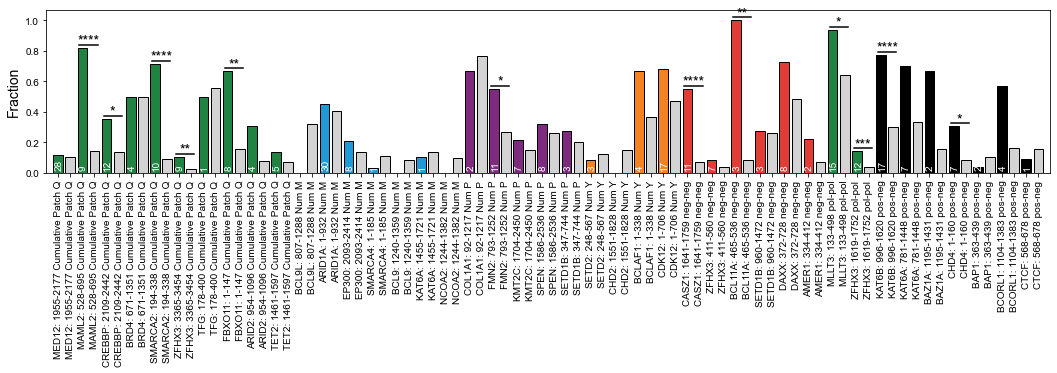

In [6]:
mycolordict={'Cumulative Patch Q':'#218342','pol-pol':'#218342','pos-neg':'#000000','neg-neg':'#e23c36','Num M':'#209ad6','Num Y':'#f58220','Num P':'#7d2a7f'}

#aamuttypes=['Deletion - Frameshift', 'Substitution - Missense', 'Substitution - Nonsense', 'Insertion - Frameshift', 'Frameshift', 'Deletion - In frame', 'Insertion - In frame']
aamuttypes=['Deletion - In frame', 'Insertion - In frame']


## Cleaned up matrix so don't repeat the same gene
expcancerIDRsdfcleaned=expcancerIDRsdf.sort_values(by=['Gene','Rank'])
#expcancerIDRsdfcleaned=expcancerIDRsdfcleaned[~expcancerIDRsdfcleaned['Feature'].isin(['Num M','Num Y','Num P'])]
expcancerIDRsdfcleaned=expcancerIDRsdfcleaned.sort_values(by=['Gene','Rank'])
expcancerIDRsdfcleaned = expcancerIDRsdfcleaned.drop_duplicates(subset=['Gene'])
expcancerIDRsdfcleaned=expcancerIDRsdfcleaned.sort_values(by=['Feature','Rank'])
print(expcancerIDRsdfcleaned)


plt.figure(figsize=(18,3))
fraclist=[]
namelist=[]
cinexpidrlist=[]
cnotinexpidrlist=[]
idrlengthlist=[]
proteinlengthlist=[]
ranklist=[]
expfeatlist=[]
genelist=[]
acclist=[]
stposlist=[]
enposlist=[]
pvallist=[]
fracindelidrlist=[]
fracseqidrlist=[]

count=-1
for i in range(0,len(expcancerIDRsdfcleaned)):
    currgene=expcancerIDRsdfcleaned['Gene'].tolist()[i].split(' ')[0]
    if currgene in goodgenes:
        currdf=pd.read_table('data/COSMIC_data/'+currgene+'_Gene_mutations_COSMIC.tsv')
        currdf=currdf[currdf['Type'].isin(aamuttypes)]
        #currdf=currdf[currdf['Type'].str.contains('In frame')]
        #currdf=currdf[currdf['Type'].str.contains('Missense')]
        currdf = currdf.drop_duplicates(subset=['CDS Mutation'])
        print(currdf)
        if len(currdf)>0:
            #print(len(currdf))
            cinexpidr=0
            cnotinexpidr=0
            for p in range(0,len(currdf)):
                if currdf['Position'].tolist()[p]>=expcancerIDRsdfcleaned['Start Pos'].tolist()[i]+1 and currdf['Position'].tolist()[p]<=expcancerIDRsdfcleaned['End Pos'].tolist()[i]:
                    cinexpidr=cinexpidr+1
                else:
                    cnotinexpidr=cnotinexpidr+1
            #print(currdf)
            #print(cinexpidr)
            #print(cnotinexpidr)

            fracindelidr=cinexpidr/(cinexpidr+cnotinexpidr)
            fracseqidr=expcancerIDRsdfcleaned['IDR Length'].tolist()[i]/expcancerIDRsdfcleaned['Full Protein Length'].tolist()[i]
            print(expcancerIDRsdfcleaned['Gene'].tolist()[i]+' '+expcancerIDRsdfcleaned['Feature'].tolist()[i])
            print(fracindelidr)
            print(fracseqidr)
            print(cinexpidr)
            print(cnotinexpidr)
            print(expcancerIDRsdfcleaned['IDR Length'].tolist()[i])
            print(expcancerIDRsdfcleaned['Full Protein Length'].tolist()[i])
            cinexpidrlist.append(cinexpidr)
            cnotinexpidrlist.append(cnotinexpidr)
            idrlengthlist.append(expcancerIDRsdfcleaned['IDR Length'].tolist()[i])
            proteinlengthlist.append(expcancerIDRsdfcleaned['Full Protein Length'].tolist()[i])
            ranklist.append(expcancerIDRsdfcleaned['Rank'].tolist()[i])
            expfeatlist.append(expcancerIDRsdfcleaned['Feature'].tolist()[i])
            genelist.append(expcancerIDRsdfcleaned['Gene'].tolist()[i])
            acclist.append(expcancerIDRsdfcleaned['Accession'].tolist()[i])
            stposlist.append(expcancerIDRsdfcleaned['Start Pos'].tolist()[i])
            enposlist.append(expcancerIDRsdfcleaned['End Pos'].tolist()[i])
            fracindelidrlist.append(fracindelidr)
            fracseqidrlist.append(fracseqidr)

            fraclist.append(fracindelidr)
            namelist.append(expcancerIDRsdfcleaned['Gene'].tolist()[i].split(' ')[0]+': '+str(expcancerIDRsdfcleaned['Start Pos'].tolist()[i]+1)+'-'+str(expcancerIDRsdfcleaned['End Pos'].tolist()[i])+' '+expcancerIDRsdfcleaned['Feature'].tolist()[i])
            count=count+1
            plt.bar(count,fracindelidr,color=mycolordict[expcancerIDRsdfcleaned['Feature'].tolist()[i]],edgecolor='black')
            plt.text(count+0.1, 0.03, str(cinexpidr), rotation=90, color='white', ha='center')

            fraclist.append(fracseqidr)
            #namelist.append(expcancerIDRsdfcleaned['Gene'].tolist()[i]+' '+expcancerIDRsdfcleaned['Feature'].tolist()[i])
            namelist.append(expcancerIDRsdfcleaned['Gene'].tolist()[i].split(' ')[0]+': '+str(expcancerIDRsdfcleaned['Start Pos'].tolist()[i]+1)+'-'+str(expcancerIDRsdfcleaned['End Pos'].tolist()[i])+' '+expcancerIDRsdfcleaned['Feature'].tolist()[i])
            count=count+1
            plt.bar(count,fracseqidr,color='lightgrey',edgecolor='black')

            data = [[cinexpidr, cnotinexpidr], [expcancerIDRsdfcleaned['IDR Length'].tolist()[i], expcancerIDRsdfcleaned['Full Protein Length'].tolist()[i]-expcancerIDRsdfcleaned['IDR Length'].tolist()[i]]]
            print(data)
            # One-sided greater used to test if greater occurrence in nucleolus
            res = fisher_exact(data, alternative='greater')
            print(res[1])
            currpval=res[1]
            print(' ')
            pvallist.append(currpval)

            if currpval<0.01 and currpval>=0.001:
                plt.plot([count-1.25,count+0.25],[max(fracindelidr,fracseqidr)+0.02,max(fracindelidr,fracseqidr)+0.02],'-k')
                plt.text(count-0.5,max(fracindelidr,fracseqidr)+0.02,'*',fontsize=14, ha='center')
            elif currpval<0.001 and currpval>=0.0001:
                plt.plot([count-1.25,count+0.25],[max(fracindelidr,fracseqidr)+0.02,max(fracindelidr,fracseqidr)+0.02],'-k')
                plt.text(count-0.5,max(fracindelidr,fracseqidr)+0.02,'**',fontsize=14, ha='center')
            elif currpval<0.0001 and currpval>=0.00001:
                plt.plot([count-1.25,count+0.25],[max(fracindelidr,fracseqidr)+0.02,max(fracindelidr,fracseqidr)+0.02],'-k')
                plt.text(count-0.5,max(fracindelidr,fracseqidr)+0.02,'***',fontsize=14, ha='center')
            elif currpval<0.00001:
                plt.plot([count-1.25,count+0.25],[max(fracindelidr,fracseqidr)+0.02,max(fracindelidr,fracseqidr)+0.02],'-k')
                plt.text(count-0.5,max(fracindelidr,fracseqidr)+0.02,'****',fontsize=14, ha='center')


plt.xticks(np.arange(0,len(namelist)),namelist,rotation=90)
plt.ylabel('Fraction',fontsize=14)
plt.xlim([-1,len(namelist)])

fracdf=pd.DataFrame()
fracdf['Gene']=genelist
fracdf['Accession']=acclist
fracdf['Feature']=expfeatlist
fracdf['Rank']=ranklist
fracdf['Start Pos']=stposlist
fracdf['End Pos']=enposlist
fracdf['IDR Length']=idrlengthlist
fracdf['Full Protein Length']=proteinlengthlist
fracdf['Fraction of Sequence Exceptional IDR']=fracseqidrlist
fracdf['Number of Mutations in Exceptional IDR']=cinexpidrlist
fracdf['Number of Mutations not in Exceptional IDR']=cnotinexpidrlist
fracdf['Fraction of Mutations Exceptional IDR']=fracindelidrlist
fracdf['P-value']=pvallist
print(fracdf)

#fracdf.to_excel('Figures/2025_04/In_frame_indel_frequency_per_exceptional_IDR_vs_IDR_length_fraction_7_features.xlsx')
#fracdf.to_excel('Figures/2025_04/'+str(len(aamuttypes))+'_mutation_types_frequency_per_exceptional_IDR_vs_IDR_length_fraction_7_features.xlsx')

#plt.savefig('Figures/2025_04/In_frame_indel_frequency_per_exceptional_IDR_vs_IDR_length_fraction.pdf', transparent=False, bbox_inches = "tight")
#plt.savefig('Figures/2025_04/'+str(len(aamuttypes))+'_mutation_types_frequency_per_exceptional_IDR_vs_IDR_length_fraction.pdf', transparent=False, bbox_inches = "tight")
#plt.savefig('Figures/2025_04/In_frame_indel_frequency_per_exceptional_IDR_vs_IDR_length_fraction_7_features.pdf', transparent=False, bbox_inches = "tight")
#plt.savefig('Figures/2025_04/'+str(len(aamuttypes))+'_mutation_types_frequency_per_exceptional_IDR_vs_IDR_length_fraction_7_features.pdf', transparent=False, bbox_inches = "tight")


## 1.5 Load in human IDR data

In [7]:
humandf=pd.read_excel('../general_data/All_sapiens_IDRs_clustermap_using_centroids.xlsx', engine='openpyxl')
humandf = humandf.fillna('')

domaindf=pd.read_excel('../general_data/sapiens_uniprot_all_domains_start_end_name.xlsx')
print(domaindf)

       Unnamed: 0   Accession                   Gene  Length  Start pos  \
0               0  A0A0K2S4Q6                 CD300H     201         25   
1               1      A0AV96                  RBM47     593         71   
2               2      A0AV96                  RBM47     593        151   
3               3      A0AV96                  RBM47     593        246   
4               4      A0FGR8  ESYT2 FAM62B KIAA1228     921        191   
...           ...         ...                    ...     ...        ...   
20776       20776      B5MCY1                 TDRD15    1934       1342   
20777       20777      B5MCY1                 TDRD15    1934       1574   
20778       20778      B5MCY1                 TDRD15    1934       1780   
20779       20779      Q2M2D7                TBC1D28     210        101   
20780       20780      Q56UQ5                    NaN     140          6   

       End pos     Domain name  
0          123  Ig-like V-type  
1          149           RRM 1  


## 1.6 - Visualize mutations within a given sequence

       Unnamed: 0 Uniprot Uniprot w IDRnum        Gene  Cluster Number  \
19446       19446  Q8IZL2         Q8IZL2_1  MAML2 IDR1              10   
19447       19447  Q8IZL2         Q8IZL2_2  MAML2 IDR2              14   
19448       19448  Q8IZL2         Q8IZL2_3  MAML2 IDR3              10   
19449       19449  Q8IZL2         Q8IZL2_4  MAML2 IDR4              11   
19450       19450  Q8IZL2         Q8IZL2_5  MAML2 IDR5              11   
19451       19451  Q8IZL2         Q8IZL2_6  MAML2 IDR6              11   
19452       19452  Q8IZL2         Q8IZL2_7  MAML2 IDR7              28   
19453       19453  Q8IZL2         Q8IZL2_8  MAML2 IDR8              10   
19454       19454  Q8IZL2         Q8IZL2_9  MAML2 IDR9              10   

       IDR Length  Start Pos  End Pos  Full Protein Length  \
19446          33          0       33                 1156   
19447         144         50      194                 1156   
19448          41        224      265                 1156   
19449      

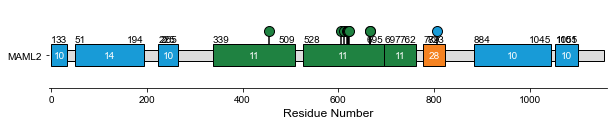

In [9]:
currgenes=['MAML2 IDR']

tmpdf=humandf[humandf['Gene'].str.contains(currgenes[0])]
print(tmpdf)

myclustercolors=['#D865A6','#7C2880','#E23A36','#E23A36','#E23A36','#000000','#1F8241','#E23A36','#E23A36','#000000','#189BD7','#1F8241','#000000','#E23A36','#189BD7','#1F8241','#1F8241','#189BD7','#000000','#E23A36','#8C8C8C','#7C2880','#D865A6','#000000','#E23A36','#189BD7','#189BD7','#7C2880','#F58220','#189BD7']


fig, ax = plt.subplots()
fig.set_size_inches(10,len(set(currgenes))*1.5)
dflen=[]
# First get max of full sequence length so can set up figure
plottedproteins=[]
plottedgenes=[]
shift=1.5
barheight=0.4
count=-1
for s in range(0,len(currgenes)):
    if currgenes[s] not in plottedproteins:
        count=count+1
        plottedproteins.append(currgenes[s])
        plottedgenes.append(currgenes[s].split(' ')[0])
        curridf=humandf[humandf['Gene'].str.contains(currgenes[s])]
        currddf=domaindf[domaindf['Accession']==curridf['Uniprot'].tolist()[0]]
        currlen=curridf['Full Protein Length'].tolist()[0]
        dflen.append(currlen)

        # Create full sequence
        ax.add_patch(Rectangle((0, len(set(currgenes))-shift*count), currlen, 0.4, edgecolor = 'black', facecolor='#DDDDDD'))

        # Create domains
        #if show_domains==True:
        for d in range(0,len(currddf)):
            currstpos=currddf['Start pos'].tolist()[d]-1
            currenpos=currddf['End pos'].tolist()[d]
            currdomain=currddf['Domain name'].tolist()[d]
            ax.add_patch(Rectangle((currstpos, len(set(currgenes))-shift*count-0.2), currenpos-currstpos, 0.4+2*0.2, edgecolor = 'black', facecolor='#FFFF00'))
            ax.text(currstpos+(currenpos-currstpos)/2,(len(set(currgenes))-shift*count-0.2)+(0.4+2*0.2)/2,currdomain,color='black',verticalalignment='center',horizontalalignment='center')


        # Create idrs
        for d in range(0,len(curridf)):
            currstpos=curridf['Start Pos'].tolist()[d]
            currenpos=curridf['End Pos'].tolist()[d]
            currclust=curridf['Cluster Number'].tolist()[d]
            ax.add_patch(Rectangle((currstpos, len(set(currgenes))-shift*count-0.2), currenpos-currstpos, 0.4+2*0.2, edgecolor = 'black', facecolor=myclustercolors[currclust]))
            ax.text(currstpos+(currenpos-currstpos)/2,(len(set(currgenes))-shift*count-0.2)+(0.4+2*0.2)/2,str(currclust),color='white',verticalalignment='center',horizontalalignment='center')
            ax.text(currstpos, len(set(currgenes))-shift*count-0.2+0.4+2*0.2+0.1,str(currstpos+1),color='black',horizontalalignment='left')
            ax.text(currenpos, len(set(currgenes))-shift*count-0.2+0.4+2*0.2+0.1,str(currenpos),color='black',horizontalalignment='right')

        # Add in mutations
        currmutdf=pd.read_table('data/COSMIC_data/'+currgenes[s].split(' ')[0]+'_Gene_mutations_COSMIC.tsv')
        #currmutdf=currmutdf[currmutdf['Type'].isin(aamuttypes)]
        currmutdf=currmutdf[currmutdf['Type'].str.contains('In frame')]
        #currmutdf=currmutdf[currmutdf['Type'].str.contains('Missense')]
        currmutdf = currmutdf.drop_duplicates(subset=['CDS Mutation'])
        print(currmutdf)
        #testdf=currmutdf[currmutdf['Position']>=3365]
        #print(testdf)
        
        countscale=5
        linelength=0.5
        for m in range(0,len(currmutdf)):
            currmut=currmutdf['AA Mutation'].tolist()[m].split('p.')[1]
            currmutaa=currmut[0]
            #plt.plot(currmutdf['Position'].tolist()[m],len(set(currgenes)),'o',markersize=math.log10(currmutdf['Count'].tolist()[m]))
            plt.plot([currmutdf['Position'].tolist()[m]+0.5, currmutdf['Position'].tolist()[m]+0.5],[len(set(currgenes))-shift*count+0.4, len(set(currgenes))-shift*count+0.4+linelength],color='#000000',zorder=-1)
            #plt.plot(currmutdf['Position'].tolist()[m]+0.5,len(set(currgenes))-shift*count+0.4+linelength,marker="o",markeredgecolor='black',markerfacecolor='green',markersize=math.log(currmutdf['Count'].tolist()[m])*countscale,zorder=5)
            plt.plot(currmutdf['Position'].tolist()[m]+0.5,len(set(currgenes))-shift*count+0.4+0.2+linelength,marker="o",markeredgecolor='black',markerfacecolor=aacolor_map[currmutaa],markersize=10,zorder=5)
            

    ax.set_yticks(list(np.arange(len(plottedproteins)+0.2, len(plottedproteins)-shift*len(plottedproteins)+0.2, -shift)))
    ax.set_yticklabels(plottedgenes)
    ax.set_xlim([-5, max(dflen)+5])
    ax.set_ylim([0, 3])
    #ax.set_ylim([len(plottedproteins)-shift*(len(plottedproteins)-1)-1, len(plottedproteins)+1])
    ax.spines[['left','right', 'top']].set_visible(False)
    ax.set_xlabel('Residue Number',fontsize=12)
    
    #plt.savefig('Figures/2025_04/'+plottedgenes[s]+'_schematic_w_in_frame_indel_positions.pdf', transparent=False, bbox_inches = "tight")
